## Place this code in the main folder of the code before running

### Check the GPU being used

In [2]:
!nvidia-smi

Tue Apr 22 09:50:14 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla V100-SXM2-32GB           On  | 00000000:18:00.0 Off |                    0 |
| N/A   43C    P0              42W / 300W |      0MiB / 32768MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

Our best checkpoints can be downloaded from [here](https://drive.google.com/drive/folders/1M4mGhf8JYSI6Bou4Mtg0nHAXZu0gsEh9?usp=sharing). 

Please refer to the README.md file in the code zip file to set up dependencies.

Place the checkpoints in some folder and paste the path to the checkpoint in the notebook.

Checkpoint reference: 

- Full adaptation (Best performing, recommended) - checkpoint_peft_decoder_adapter.pth
- Half adaptation - checkpoint_peft_no_decoder_adapter.pth
- Partial baseline - half_frozen_baseline.pth
- Frozen baseline - full_frozen_baseline.pth



### Import libraries and create the model

Set MODEL_WITH_DECODER_ADAPTER = True if you are using the model with the decoder adapter

For Half adaptation and Full adaptation set MODEL_NAME = "ReMamber_Conv_PEFT"
For baseline models set MODEL_NAME = "ReMamber_PEFT"

In [82]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" # NOTE: use this to select GPU
import torch
from timm.models import create_model

import model.conv_segmenter_peft
import model.conv_segmenter
import utils as utils
from ref_dataset import get_transform_seg


DEVICE = torch.device("cuda")
SEED = 42
MODEL_NAME = "ReMamber_Conv_PEFT" # or "ReMamber_Conv" for baseline variants

MODEL_WITH_DECODER_ADAPTER = True
# Set this to true for the model with decoder adapter (Full Adaptation version),  or else errors will come)
# If you are using the model with no decoder adapter (Half Adaptation), set it to False.


#CKPT_PATH = "outputs/checkpoint_model:de3e9b2b.pth" 
#CKPT_PATH = "outputs/checkpoint_model:4cb71664.pth"

#CKPT_PATH = "load the path to the checkpoint here"

demo_model, new_param = create_model(
    MODEL_NAME,
    img_size=480,
    model_size="base",
    use_adapters=MODEL_WITH_DECODER_ADAPTER
)

checkpoint = torch.load(CKPT_PATH, map_location='cpu')
demo_model.load_state_dict(checkpoint['model'])
demo_model.to(DEVICE)
demo_model.eval()
transforms = get_transform_seg(size=(480,480), train=False)

kwargs {'use_adapters': True}
Finetuning half decoder with adapters
True


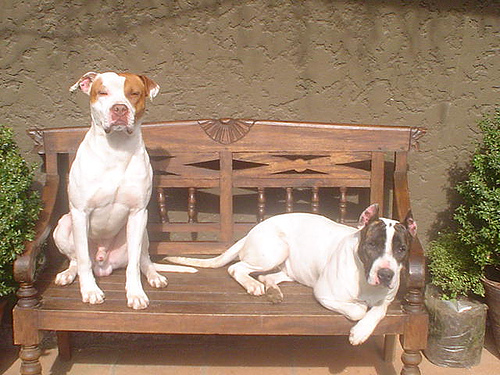

In [71]:
# read the image
from PIL import Image
input_img = Image.open("assets/demo_image.jpg")
input_img

In [72]:
# image transform and model inference
img = transforms(input_img, torch.zeros(1,480,480))[0].unsqueeze(0).to(DEVICE)
txt = "The left dog"
output = demo_model(img, [txt])
output.shape

torch.Size([1, 1, 480, 480])

output.shape

Input text: The left dog


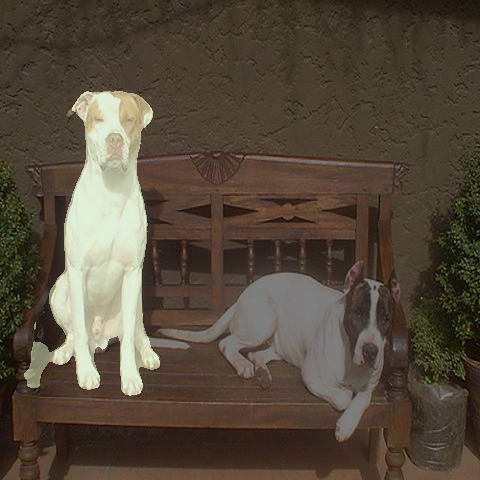

In [73]:
# show result
pred = (output.sigmoid().cpu().detach().squeeze() > 0.5).unsqueeze(-1)
color = torch.tensor([197,224,180]).unsqueeze(0)
pred_mask = Image.fromarray((pred*color).numpy().astype('uint8'))
print("Input text:", txt)
Image.blend(input_img.resize((480,480)), pred_mask, alpha=0.5)

In [74]:
# image transform and model inference
img = transforms(input_img, torch.zeros(1,480,480))[0].unsqueeze(0).to(DEVICE)
txt = "The left dog and right dog"
output = demo_model(img, [txt])
output.shape

torch.Size([1, 1, 480, 480])

output.shape

Input text: The left dog and right dog


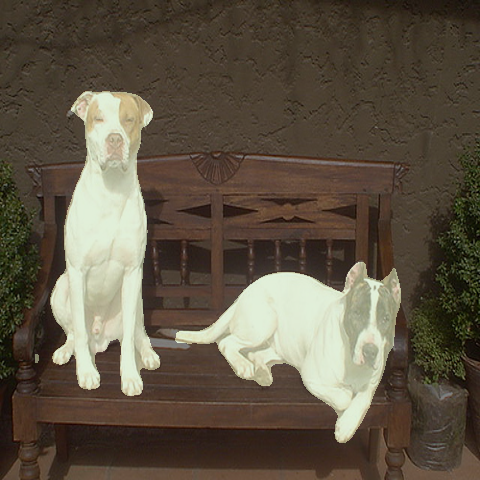

In [75]:
# show result
pred = (output.sigmoid().cpu().detach().squeeze() > 0.5).unsqueeze(-1)
color = torch.tensor([197,224,180]).unsqueeze(0)
pred_mask = Image.fromarray((pred*color).numpy().astype('uint8'))
print("Input text:", txt)
Image.blend(input_img.resize((480,480)), pred_mask, alpha=0.5)

In [76]:
# image transform and model inference
img = transforms(input_img, torch.zeros(1,480,480))[0].unsqueeze(0).to(DEVICE)
txt = "The left car"
output = demo_model(img, [txt])
output.shape

torch.Size([1, 1, 480, 480])

output.shape

Input text: The left car


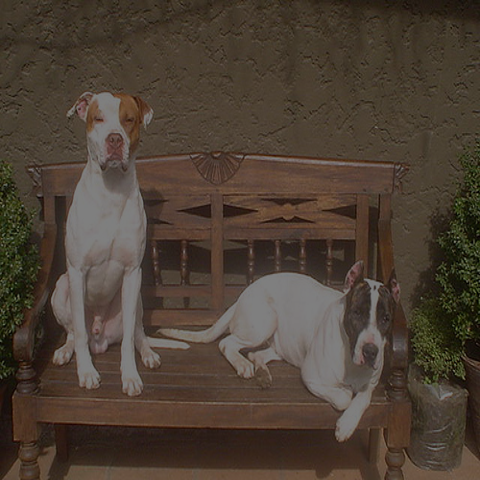

In [77]:
# show result
pred = (output.sigmoid().cpu().detach().squeeze() > 0.5).unsqueeze(-1)
color = torch.tensor([197,224,180]).unsqueeze(0)
pred_mask = Image.fromarray((pred*color).numpy().astype('uint8'))
print("Input text:", txt)
Image.blend(input_img.resize((480,480)), pred_mask, alpha=0.5)

In [78]:
# image transform and model inference
img = transforms(input_img, torch.zeros(1,480,480))[0].unsqueeze(0).to(DEVICE)
txt = "The left plant, the right dog, and the right plant"
output = demo_model(img, [txt])
output.shape

torch.Size([1, 1, 480, 480])

output.shape

Input text: The left plant, the right dog, and the right plant


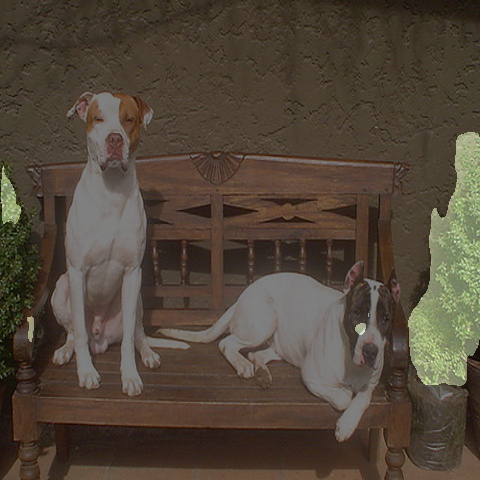

In [79]:
# show result
pred = (output.sigmoid().cpu().detach().squeeze() > 0.5).unsqueeze(-1)
color = torch.tensor([197,224,180]).unsqueeze(0)
pred_mask = Image.fromarray((pred*color).numpy().astype('uint8'))
print("Input text:", txt)
Image.blend(input_img.resize((480,480)), pred_mask, alpha=0.5)